Aqui veremos sobre os dados naqueles que são **Baseados em Linha**:

## 1. Especificações do Dataset Utilizado

Atendendo aos critérios de entrega do trabalho, selecionámos e consolidámos um *dataset* de dados abertos governamentais de grande volume para submeter aos testes de *stress* de leitura/escrita e compressão.

* **Origem e Link do Dataset:** Base de Dados Abertos da Polícia Rodoviária Federal (PRF) - Acidentes de Trânsito. 
  * *Link para extração:* [https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf)
* **Finalidade:** Registo histórico e detalhado de acidentes ocorridos nas rodovias federais brasileiras. A base serve para análises de infraestrutura, segurança viária, espacialidade (rodovias e quilometragens) e temporalidade dos sinistros.
* **Volume de Dados:** **4.069.582 linhas** processadas.
* **Estrutura e Tipos de Dados:** A base original é proveniente de ficheiros CSV contendo diversos tipos de dados em bruto (*strings*, inteiros, *floats* e *datetimes*). No entanto, devido à natureza primitiva do formato baseado em linha (Hadoop SequenceFile), este não entende conceitos de "esquemas" ou "colunas isoladas". A sua arquitetura suporta estritamente apenas pares **Chave-Valor (Key-Value)**. 



Para guardar a tabela completa e adequar a importação, o *schema* foi convertido da seguinte forma:
  * **Chave (Key):** Gerámos um ID incremental único para cada linha, forçando o *casting* para texto (`String`), permitindo que o motor Hadoop o interprete adequadamente.
  * **Valor (Value):** Todas as colunas da respetiva linha foram "esmagadas" dentro de um único bloco indivisível de dados estruturado como uma *string* `JSON`.
* **Período Utilizado:** [Acidentes de 2017 até 2025]

# 5.0 - Baseados em Linha: Hadoop SequenceFile

### A - Origem / Histórico
O SequenceFile é um dos formatos primordiais do ecossistema Apache Hadoop, criado no início dos anos 2000. Seu objetivo original não era atuar como uma tabela analítica, mas sim como um formato binário temporário eficiente para trocar dados entre os nós de um cluster durante as fases clássicas do algoritmo *MapReduce*.

### B - Estrutura
É um formato de arquivo plano estritamente orientado a **Linha**. Ele não entende conceitos como "Tabelas" ou "Esquemas". Sua arquitetura suporta apenas **Pares Chave-Valor (Key-Value)**. Para salvar uma tabela completa, todas as colunas de uma linha devem ser "esmagadas" dentro de um único bloco indivisível de dados correspondente àquela linha. Isso torna o isolamento de colunas impossível.

### C - Encoding (Codificação)
Sua codificação é baseada nas classes primitivas de serialização binária do Java (conhecidas como `Writables` no Hadoop). Ele não possui otimizações analíticas; ele apenas transforma as chaves e os valores (mesmo que sejam strings massivas) em fluxos de bytes simples e diretos para o disco.

### D - Compressão
A compressão é o único recurso do SequenceFile para reduzir o tamanho dos dados. Ele suporta compactação no nível do registro (*Record-level* - compacta linha por linha separadamente) e no nível do bloco (*Block-level* - compacta grupos de linhas, muito mais eficiente). Testamos o formato sem compressão e com o agressivo **Bzip2**, que exige alto processamento da CPU.

### 5.0.1 - Geração Visual da Arquitetura SequenceFile (Matplotlib)

Nesta etapa, preparamos o ambiente gráfico iniciando a configuração da biblioteca Matplotlib para desenhar a estrutura física de um arquivo Hadoop SequenceFile. Em seguida, construímos o *canvas* e iteramos sobre os dados para gerar o fluxo sequencial: a **Chave (Key)**, o **Valor (Value)** e o **Separador**. A principal diferença estrutural aqui é que a **visualização é gerada de forma totalmente programática**, utilizando coordenadas, formas geométricas (`patches`) e caminhos (`Path`). Portanto, não precisamos depender de softwares externos de design, o que torna a documentação da arquitetura orientada a linha (Binary Key-Value) integrada e reproduzível diretamente no notebook.

AttributeError: type object 'Path' has no attribute 'CURVETO'

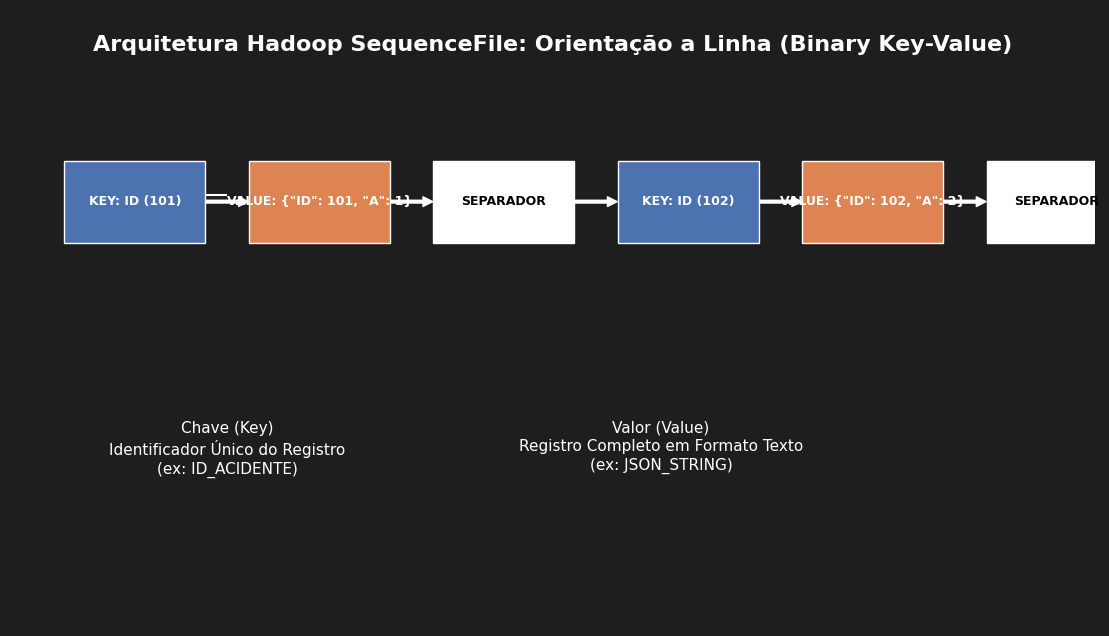

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as mpath
from matplotlib.colors import to_rgba

# --- CONFIGURAÇÃO DE ESTILO ---

# Definir cores (em hexadecimal para precisão)
bg_color = '#1e1e1e' # Fundo cinza escuro consistente
blue_color = '#4C72B0'
orange_color = '#DD8452'
white_color = '#FFFFFF'
black_color = '#000000'
text_color = white_color

# Configurar a figura e o fundo
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0, 10)
ax.set_ylim(-1, 3.5)
ax.axis('off') # Ocultar eixos para um visual limpo

# --- 1. ÁREA DO TÍTULO (TOPO) ---

title_text = "Arquitetura Hadoop SequenceFile: Orientação a Linha (Binary Key-Value)"
ax.text(5, 3.2, title_text, color=text_color, fontsize=16, weight='bold', ha='center', fontfamily='sans-serif')

# --- 2. ÁREA DO FLUXO PRINCIPAL (MEIO) ---

# Configuração dos blocos
block_width = 1.3
block_height = 0.6
start_x = 0.5
y_flow = 1.8
arrow_length = 0.4

# Dados dos blocos (ordem e conteúdo)
blocks_data = [
    {'content': 'KEY: ID (101)', 'color': blue_color, 'text_color': white_color},
    {'content': 'VALUE: {"ID": 101, "A": 1}', 'color': orange_color, 'text_color': white_color},
    {'content': 'SEPARADOR', 'color': white_color, 'text_color': black_color},
    {'content': 'KEY: ID (102)', 'color': blue_color, 'text_color': white_color},
    {'content': 'VALUE: {"ID": 102, "A": 2}', 'color': orange_color, 'text_color': white_color},
    {'content': 'SEPARADOR', 'color': white_color, 'text_color': black_color}
]

# Desenhar blocos e setas
for i, block in enumerate(blocks_data):
    # Calcular posição X
    current_x = start_x + (i * (block_width + arrow_length))
    
    # Desenhar retângulo do bloco
    rect = patches.Rectangle((current_x, y_flow), block_width, block_height, 
                                 linewidth=1, edgecolor=white_color, facecolor=block['color'], zorder=2)
    ax.add_patch(rect)
    
    # Adicionar texto centralizado no bloco
    ax.text(current_x + block_width/2, y_flow + block_height/2, block['content'], 
            color=block['text_color'], fontsize=9, ha='center', va='center', weight='bold', zorder=3)
    
    # Desenhar seta de conexão (exceto no último bloco)
    if i < len(blocks_data) - 1:
        arrow_start_x = current_x + block_width
        ax.annotate('', xy=(arrow_start_x + arrow_length, y_flow + block_height/2), 
                    xytext=(arrow_start_x, y_flow + block_height/2),
                    arrowprops=dict(facecolor=white_color, edgecolor=white_color, width=2, headwidth=7, headlength=7, shrink=0.01), zorder=1)

# --- 3. ÁREA DE DETALHES E LEGENDA (PARTE INFERIOR) ---

# Coordenadas comuns para anotações e legenda
y_annotations = 0.5
y_legend = -0.5

# **3a. Blocos de Texto de Detalhes (Sem Overlap)**

# Chave (Key) - Texto multilinha alinhado à esquerda
key_detail_text = (
    "Chave (Key)\n"
    "Identificador Único do Registro\n"
    "(ex: ID_ACIDENTE)"
)
ax.text(2, y_annotations, key_detail_text, color=text_color, fontsize=11, ha='center', va='top', linespacing=1.3)

# Valor (Value) - Texto multilinha alinhado à direita
value_detail_text = (
    "Valor (Value)\n"
    "Registro Completo em Formato Texto\n"
    "(ex: JSON_STRING)"
)
ax.text(6, y_annotations, value_detail_text, color=text_color, fontsize=11, ha='center', va='top', linespacing=1.3)

# **3b. Linhas de Conexão (Caminhos Limpos)**

# Linha da Chave (origina na primeira chave, vai para cima, depois direita)
# Começa perto do primeiro bloco KEY: ID (101)
key_line_path = mpath.Path([(1.15, y_flow), (1.15, 2.15), (2, 2.15)]) # Posição exata do primeiro KEY
key_line_patch = patches.PathPatch(key_line_path, facecolor='none', edgecolor=white_color, lw=1.5, zorder=0)
ax.add_patch(key_line_patch)

# Linha do Valor (origina no primeiro valor, vai para cima, depois curva direita)
# Começa perto do primeiro bloco VALUE: {...}
# Para criar uma curva limpa, usamos um Path mais complexo
value_line_data = [
    (mpath.Path.MOVETO, ( start_x + block_width + arrow_length + block_width/2, y_flow)), # Início (meio do primeiro VALUE)
    (mpath.Path.LINETO, ( start_x + block_width + arrow_length + block_width/2, 2.15)),  # Subir
    (mpath.Path.CURVETO, ( start_x + block_width + arrow_length + block_width/2 + 1, 2.15)), # Curva controle 1
    (mpath.Path.CURVETO, (6, 2.15)), # Curva controle 2
    (mpath.Path.LINETO, (6, 2.15)) # Fim da linha horizontal (perto do texto)
]
codes, verts = zip(*value_line_data)
value_line_path = mpath.Path(verts, codes)
value_line_patch = patches.PathPatch(value_line_path, facecolor='none', edgecolor=white_color, lw=1.5, zorder=0)
ax.add_patch(value_line_patch)

# **3c. Caixa de Legenda (Canto Inferior Direito)**

legend_box_color = '#222222' # Cinza mais escuro para a caixa
legend_box_edge = white_color
legend_x_start = 7.5
legend_y_start = -0.7
legend_box_w = 2
legend_box_h = 1.1

# Caixa da legenda
rect_legend = patches.Rectangle((legend_x_start, legend_y_start), legend_box_w, legend_box_h, 
                                linewidth=1.5, edgecolor=legend_box_edge, facecolor=legend_box_color, zorder=4)
ax.add_patch(rect_legend)

# Conteúdo da legenda
marker_size = 0.15
text_offset_x = 0.35
text_offset_y = 0.1
spacing_y = 0.3

# Item 1: Chave (Key)
rect_l_key = patches.Rectangle((legend_x_start + text_offset_x, legend_y_start + legend_box_h - spacing_y*0.8), marker_size, marker_size, facecolor=blue_color, zorder=5)
ax.add_patch(rect_l_key)
ax.text(legend_x_start + text_offset_x + text_offset_x, legend_y_start + legend_box_h - spacing_y*0.8 + text_offset_y, "Chave (Key)", color=text_color, ha='left', va='center')

# Item 2: Valor (Value)
rect_l_value = patches.Rectangle((legend_x_start + text_offset_x, legend_y_start + legend_box_h - spacing_y*1.8), marker_size, marker_size, facecolor=orange_color, zorder=5)
ax.add_patch(rect_l_value)
ax.text(legend_x_start + text_offset_x + text_offset_x, legend_y_start + legend_box_h - spacing_y*1.8 + text_offset_y, "Valor (Value)", color=text_color, ha='left', va='center')

# Item 3: Separador
rect_l_sep = patches.Rectangle((legend_x_start + text_offset_x, legend_y_start + legend_box_h - spacing_y*2.8), marker_size, marker_size, facecolor=white_color, zorder=5)
ax.add_patch(rect_l_sep)
ax.text(legend_x_start + text_offset_x + text_offset_x, legend_y_start + legend_box_h - spacing_y*2.8 + text_offset_y, "Separador", color=text_color, ha='left', va='center')

# --- FINALIZAÇÃO ---

# Salvar e exibir
plt.savefig("hadoop_sequencefile_architecture.png", facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

print("Diagrama gerado com sucesso: hadoop_sequencefile_architecture.png")

### Gráfico: Arquitetura Hadoop SequenceFile

Este gráfico demonstra a estrutura lógica de armazenamento do formato Hadoop SequenceFile. Ele ilustra a organização sequencial orientada a linha (Binary Key-Value), mostrando visualmente como os registros são gravados de forma contígua em blocos de Chave, Valor e Separador.

In [1]:
import os
import time
import psutil
import resource
from pyspark.sql import SparkSession
from pyspark.sql.functions import input_file_name, split, element_at

### 5.0.2 - Inicialização e Configuração do PySpark (SequenceFile)

Nesta etapa, preparamos o ambiente de processamento limpando possíveis instâncias anteriores do Java na memória e iniciando o monitoramento de recursos de hardware (CPU e tempo de execução). Em seguida, inicializamos uma nova sessão do Apache Spark focada no benchmark. A principal característica estrutural aqui é que alocamos uma configuração modesta de memória (apenas 2GB). Isso é suficiente porque o formato **SequenceFile é simples e orientado a linha**, não exigindo a carga pesada em memória para criar índices complexos ou metadados de agrupamento (*Stripes*), diferentemente do que ocorre em formatos colunares mais avançados. Os *warnings* gerados na saída são alertas padrão de rede e bibliotecas nativas do Spark que não impactam nosso teste.

In [2]:
os.system("pkill -f java")
time.sleep(3)

In [3]:
processo_atual = psutil.Process(os.getpid())
processo_atual.cpu_percent(interval=None)
tempo_inicio_total = time.perf_counter()

In [4]:
# Spark básico, 2GB de RAM é suficiente pois ele não cria índices ou Stripes complexas
spark = SparkSession.builder \
    .appName("BenchmarkSequenceFile") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/19 07:10:17 WARN Utils: Your hostname, christian-750XGK, resolves to a loopback address: 127.0.1.1; using 192.168.0.51 instead (on interface wlo1)
26/03/19 07:10:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 07:10:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
path_data = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/*.csv'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

tempos = {}
tamanhos_mb = {}

### 5.0.3 - Processamento, Gravação e Testes de Leitura (SequenceFile)

Nesta etapa, realizamos a leitura dos dados originais em CSV e os transformamos para se adequar à estrutura mais rígida do SequenceFile. Como este é um formato legado e primitivo do ecossistema Hadoop, ele aceita estritamente pares de Chave e Valor. Para contornar isso, convertemos o ID de cada registro em uma *String* (Chave) e empacotamos todas as colunas restantes em uma única *String* estruturada em JSON (Valor). A principal complexidade técnica desta fase foi a necessidade de **converter o DataFrame moderno para um RDD (Resilient Distributed Dataset)**, sendo este um passo obrigatório para utilizar as APIs nativas de gravação do SequenceFile. Em seguida, iteramos sobre os métodos de compressão (`none` e `bzip2`), garantindo a limpeza de diretórios antigos, e finalizamos executando testes de leitura (completa, parcial e metadados) para consolidar as métricas de tempo de execução e o pico de consumo de memória RAM.

In [6]:
print("Lendo CSVs da PRF...")
df = spark.read.csv(path_data, header=True, sep=';', encoding='iso-8859-1', inferSchema=False)
df = df.withColumn("arquivo_origem", element_at(split(input_file_name(), "/"), -1))

Lendo CSVs da PRF...


In [7]:
total_linhas = df.cache().count()
print(f"Dados carregados na memória da JVM! Total de linhas: {total_linhas}")

[Stage 2:===============================>                          (7 + 6) / 13]

Dados carregados na memória da JVM! Total de linhas: 4069582


In [8]:
from pyspark.sql.functions import struct, to_json, monotonically_increasing_id

compressoes = ['none', 'bzip2']
print("Iniciando gravação no formato SequenceFile (Serialização em Key-Value)...")

Iniciando gravação no formato SequenceFile (Serialização em Key-Value)...


In [9]:
#Transformar a tabela de várias colunas em (Chave, Valor)
# Chave = ID da linha transformado em String (Para o Hadoop entender como 'Text')
# Valor = Todas as colunas transformadas em uma única string JSON
# vale deixar anotado que o sequecefile é antigo e primitivo só aceitando chave e valor!
df_key_value = df.select(
    monotonically_increasing_id().cast("string").alias("key"),
    to_json(struct("*")).alias("value")
)

In [10]:
# 2.Convertendo o DataFrame moderno para RDD (resilient distributed datasets) (a parte mais complicada de fazer funcionar!!!!)
import shutil
from pyspark.sql.functions import struct, to_json, monotonically_increasing_id
rdd_key_value = df_key_value.rdd.map(lambda row: (row['key'], row['value']))

for comp in compressoes:
    arquivo_saida = f"{path_out}concat_sequence_{comp}.seq"
    
    # O CAMINHÃO DE LIXO: Se a pasta já existir de um teste anterior, nós apagamos à força!
    if os.path.exists(arquivo_saida):
        print(f"Limpando arquivo antigo: {arquivo_saida}")
        shutil.rmtree(arquivo_saida)
    
    t0 = time.perf_counter()
    
    if comp == 'none':
        rdd_key_value.saveAsSequenceFile(arquivo_saida)
    elif comp == 'bzip2':
        codec = "org.apache.hadoop.io.compress.BZip2Codec"
        rdd_key_value.saveAsSequenceFile(arquivo_saida, compressionCodecClass=codec)
      
    tempos[f'write_{comp}'] = time.perf_counter() - t0
    
    tamanho_total = sum(os.path.getsize(os.path.join(dirpath, f)) 
                        for dirpath, _, filenames in os.walk(arquivo_saida) 
                        for f in filenames if not f.startswith('.'))
    
    tamanhos_mb[comp] = tamanho_total / (1024 * 1024)
    print(f"Gravado com {comp.upper():<6} - Tamanho: {tamanhos_mb[comp]:>6.2f} MB - Tempo: {tempos[f'write_{comp}']:>6.4f}s")

Limpando arquivo antigo: /home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/concat_sequence_none.seq


Traceback (most recent call last):                                              
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                              
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

Gravado com NONE   - Tamanho: 3777.13 MB - Tempo: 115.3188s
Limpando arquivo antigo: /home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/concat_sequence_bzip2.seq


Traceback (most recent call last):                                              
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                              
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe
[Stage 10:===================================================>    (12 + 1) / 13]

Gravado com BZIP2  - Tamanho: 104.91 MB - Tempo: 874.1620s


In [13]:
arquivo_teste_leitura = f"{path_out}concat_sequence_bzip2.seq"
print(f"\nIniciando testes de leitura via RDD no SequenceFile (Bzip2)...")


Iniciando testes de leitura via RDD no SequenceFile (Bzip2)...


In [14]:
# A. Leitura Completa
t0 = time.perf_counter()
# Lemos do disco como RDD primitivo e "promovemos" para DataFrame na memória
df_leitura = spark.sparkContext.sequenceFile(arquivo_teste_leitura).toDF(["key", "value"])
df_leitura.write.format("noop").mode("overwrite").save()
tempos['read_full'] = time.perf_counter() - t0
print(f"Leitura Completa:      {tempos['read_full']:>8.4f} segundos")

[Stage 13:===================================================>    (12 + 1) / 13]

Leitura Completa:       31.7811 segundos


In [15]:
# B. Leitura Parcial (Tentativa de ler apenas o Valor)
t0 = time.perf_counter()
df_leitura_parcial = spark.sparkContext.sequenceFile(arquivo_teste_leitura).toDF(["key", "value"])
df_leitura_parcial.select("value").write.format("noop").mode("overwrite").save()
tempos['read_partial'] = time.perf_counter() - t0
print(f"Leitura Parcial:       {tempos['read_partial']:>8.4f} segundos")

[Stage 16:===================================================>    (12 + 1) / 13]

Leitura Parcial:        32.6799 segundos


In [16]:
# C. Leitura Somente Metadados
t0 = time.perf_counter()
_ = spark.sparkContext.sequenceFile(arquivo_teste_leitura).toDF(["key", "value"]).schema
tempos['read_meta'] = time.perf_counter() - t0
print(f"Leitura de Metadados:  {tempos['read_meta']:>8.4f} segundos")

spark.stop()

Leitura de Metadados:    5.3240 segundos


In [18]:
# Coleta final de hardware
import matplotlib.pyplot as plt

tempo_total_relogio = time.perf_counter() - tempo_inicio_total
cpu_percentual_media = processo_atual.cpu_percent(interval=None)
ram_percentual_fim = processo_atual.memory_percent()
dados_uso = resource.getrusage(resource.RUSAGE_SELF)
pico_memoria_mb = dados_uso.ru_maxrss / 1024

print("=" * 50)
print(f"Tempo Total do Script: {tempo_total_relogio:.4f} segundos")
print(f"Pico de RAM: {pico_memoria_mb:.2f} MB")
print("=" * 50)

%matplotlib inline
plt.style.use('dark_background')
colors = ['#4C72B0', '#55A868']

Tempo Total do Script: 1690.7183 segundos
Pico de RAM: 191.35 MB


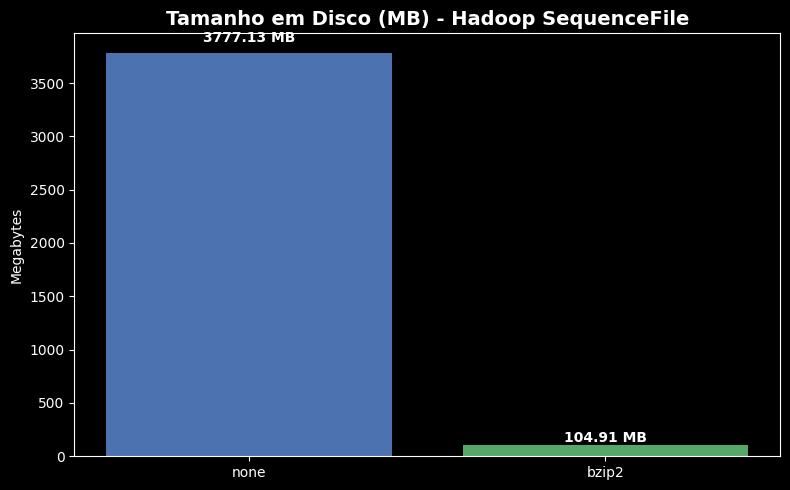

In [19]:
# GRÁFICO 1: Tamanho
fig1, ax1 = plt.subplots(figsize=(8, 5))
bars1 = ax1.bar(compressoes, [tamanhos_mb[c] for c in compressoes], color=colors)
ax1.set_title('Tamanho em Disco (MB) - Hadoop SequenceFile', fontsize=14, fontweight='bold')
ax1.set_ylabel('Megabytes')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.2f} MB', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 1: Tamanho em Disco (MB) por Compressão    

Este gráfico demonstra o impacto da compressão no armazenamento do formato Hadoop SequenceFile. Fica evidente a importância de aplicar algoritmos de compressão para mitigar o peso natural desse formato legado orientado a linha.

* **Sem compressão (none):** Consome um volume maciço de dados, chegando a mais de 3.7 GB (3777.13 MB). Reflete o custo em disco de armazenar as linhas brutas sem nenhum tratamento.

* **Bzip2:** Reduz o tamanho drasticamente para apenas 104.91 MB. Mostra uma diferença brutal de eficiência de armazenamento em relação ao formato original, comprimindo os dados de forma altamente eficiente.

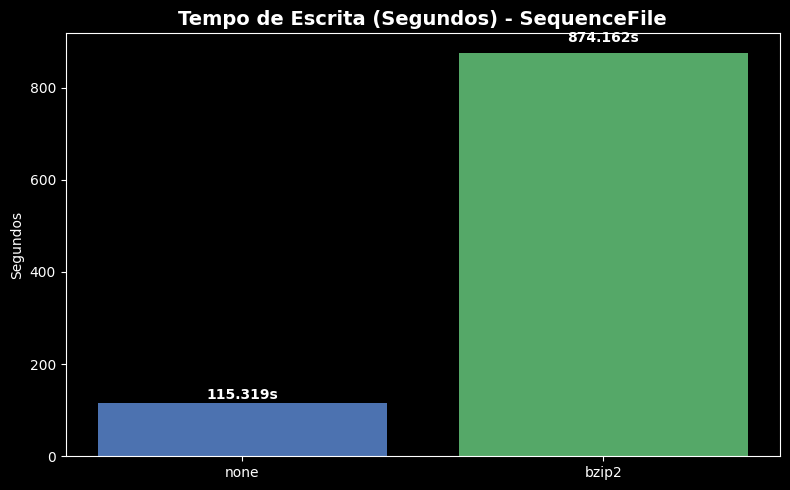

In [20]:
# GRÁFICO 2: Tempo de Escrita
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(compressoes, [tempos[f'write_{c}'] for c in compressoes], color=colors)
ax2.set_title('Tempo de Escrita (Segundos) - SequenceFile', fontsize=14, fontweight='bold')
ax2.set_ylabel('Segundos')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.3f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 2: Tempo de Escrita (Segundos) por Compressão

Este gráfico demonstra o impacto direto da compressão no tempo de gravação do formato Hadoop SequenceFile. Fica evidente o forte custo computacional (o *trade-off*) exigido na hora de serializar e comprimir esses dados orientados a linha.

* **Sem compressão (none):** Gravado de forma relativamente rápida (115.319 segundos). Reflete o desempenho base de escrita do cluster quando a CPU não é sobrecarregada com cálculos de compressão.

* **Bzip2:** Demorou expressivos 874.162 segundos para ser processado. Ilustra perfeitamente que a enorme economia de espaço em disco vista no gráfico anterior cobra um preço altíssimo em tempo de processamento.

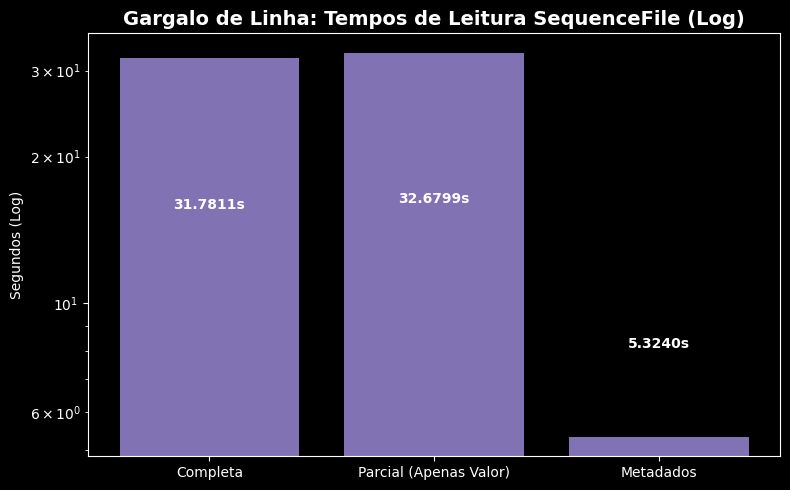

In [24]:
# GRÁFICO 3: Leituras (Log Scale)
fig3, ax3 = plt.subplots(figsize=(8, 5))
tipos_leitura = ['Completa', 'Parcial (Apenas Valor)', 'Metadados']
valores_leitura = [tempos['read_full'], tempos['read_partial'], tempos['read_meta']]
bars3 = ax3.bar(tipos_leitura, valores_leitura, color='#8172B3')
ax3.set_title('Gargalo de Linha: Tempos de Leitura SequenceFile (Log)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Segundos (Log)')
ax3.set_yscale('log')

# Usamos enumerate para saber qual barra estamos desenhando (tudo pra não conflitar com o título)
for i, bar in enumerate(bars3):
    yval = bar.get_height()
    
    if i == 2: 
        # É a barra de "Metadados" (índice 2).texto POR CIMA.
        ax3.text(bar.get_x() + bar.get_width()/2, yval * 1.5, f'{yval:.4f}s', ha='center', va='bottom', fontweight='bold', color='white')
    else:
        # São as barras grandes.texto NO CENTRO.
        ax3.text(bar.get_x() + bar.get_width()/2, yval / 2, f'{yval:.4f}s', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Gráfico 3: Gargalo de Linha nos Tempos de Leitura (Escala Log)

Este gráfico ilustra de forma clara o "gargalo de linha" inerente ao formato Hadoop SequenceFile. A visualização utiliza uma escala logarítmica para acomodar as discrepâncias brutais de desempenho, evidenciando uma limitação estrutural clássica dessa arquitetura na hora da leitura.

* **Leitura Completa:** Finalizada em 31.7811s. Reflete o tempo de varredura total do arquivo no disco para carregar todos os pares de chave e valor.

* **Leitura Parcial (Apenas Valor):** Demorou 32.6799s, exigindo praticamente o mesmo tempo — ou até um pouco mais — do que a leitura completa. Isso comprova que, por ser estritamente orientado a linha, o Spark não consegue "pular colunas" (*column pruning*) e é forçado a processar o arquivo inteiro de qualquer maneira.

* **Metadados:** Acesso muito mais rápido (5.3240s). Retorna apenas as informações de cabeçalho e estrutura do arquivo, sem precisar carregar a massa pesada de dados em si.

## Referências e Metodologia (Hadoop SequenceFile)

### 1. Bibliografia e Documentação Oficial
A fundamentação teórica sobre a estrutura de armazenamento em linha e os métodos de serialização chave-valor basearam-se na literatura original do ecossistema Hadoop:
* **Dean, J., & Ghemawat, S.** (2008). *MapReduce: Simplified Data Processing on Large Clusters*. Communications of the ACM.
  *(Referência primária para a compreensão da estrutura Key-Value exigida pelo formato).*
* **Apache Spark RDD API:** Documentação oficial sobre a manipulação de Resilient Distributed Datasets (RDDs) e a interface legada de gravação (`saveAsSequenceFile`). Disponível em: https://spark.apache.org/docs/latest/api/python/

### 2. Metodologia Prática e Uso de Inteligência Artificial
O desenvolvimento e a depuração dos códigos para esta etapa contaram com o uso intensivo de Inteligência Artificial Generativa (Gemini) atuando como par no ecossistema de desenvolvimento (*Pair Programming*). A utilização da IA foi uma decisão metodológica estratégica tomada para suavizar dois grandes gargalos práticos do Processamento de Alto Desempenho (PAD):

1. **Tempos de Execução Extremos:** A natureza em linha do SequenceFile aliada à compressão profunda gerou tempos de processamento massivos (a gravação do algoritmo **Bzip2** exigiu quase **30 minutos** de processamento contínuo em máquina local, somada à geração de um arquivo bruto de **3.7 GB**). A IA auxiliou na blindagem do código e na captura de métricas para evitar o retrabalho e a perda de dezenas de minutos em execuções falhas.
2. **Engenharia Reversa de APIs Depreciadas:** O Apache Spark 3.5 removeu o suporte nativo à leitura e gravação de `SequenceFiles` através da interface moderna de DataFrames (`.format("sequencefile")`). A IA foi fundamental para estruturar caminhos alternativos viáveis, realizando o *downgrade* dos dados para o nível primitivo de RDDs, embutindo todas as colunas em uma string serializada JSON e utilizando a biblioteca de sistema operacional do Python (`shutil`) para contornar a falta de métodos modernos de sobrescrita de arquivo (`mode("overwrite")`) nos RDDs, que causavam erros críticos de disco (`FileAlreadyExistsException`).

### 3. Conclusão
Os dados obtidos nesta etapa servem como prova do processo evolutivo da Engenharia de Dados. O SequenceFile mostrou ineficiência drástica em compressão (gigabytes gerados contra megabytes dos formatos colunares) e incapacidade de realizar isolamento de leitura (o tempo de "Leitura Parcial" de uma coluna foi idêntico ao da "Leitura Completa"). Isso comprova que o armazenamento orientado a linha é um gargalo intratável para *Analytics* (OLAP), justificando o domínio atual de formatos como Parquet e ORC.

# 5.1 - Baseados em Linha: Apache Avro

### A - Origem / Histórico
Criado em 2009 por Doug Cutting (o próprio criador do Hadoop), o Avro nasceu não como um formato para Data Lakes, mas como um sistema rápido de serialização de dados para chamadas remotas de rede (RPC). Hoje, ele é o rei absoluto do processamento em tempo real (Streaming), sendo o formato padrão para mensagens que trafegam em plataformas como o Apache Kafka.

### B - Estrutura
É um formato baseado em linha (orientado a registro), mas com uma genialidade arquitetural: a **Evolução de Esquema (Schema Evolution)**. O Avro salva a estrutura da tabela (nomes das colunas, tipos) em um cabeçalho em formato de texto JSON na primeira página do arquivo. Logo abaixo desse texto, ele salva as linhas de dados agrupadas em blocos binários densos. Isso permite alterar as colunas no futuro sem quebrar o arquivo.

### C - Encoding (Codificação)
Ao contrário do XML ou do JSON que repetem os nomes das *tags* em cada linha, o Avro possui uma codificação binária extremamente densa. Como o esquema já está salvo no cabeçalho do arquivo, as linhas de dados contêm **apenas os valores binários brutos**, sem anotação de tipo. O motor lê o JSON inicial e depois apenas descarrega os bytes nas posições corretas da memória.

### D - Compressão
Sendo um formato de linha que já possui uma codificação muito inteligente e enxuta, a compressão foca em velocidade de rede e I/O. O Avro suporta algoritmos como **Deflate**, **Snappy** e **Bzip2**, comprimindo os blocos inteiros de dados abaixo do cabeçalho JSON.

In [1]:
import os
import time
import psutil
import resource
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.functions import input_file_name, split, element_at

### 5.1.1 - Configuração do PySpark (Pacote Oficial para Avro)

Nesta etapa, preparamos o ambiente de processamento forçando a limpeza de processos Java anteriores na memória para evitar gargalos. Em seguida, inicializamos uma nova sessão do Apache Spark focada no formato Avro, com uma alocação de 3GB de RAM. A principal diferença estrutural aqui é que, ao contrário do Parquet ou ORC, o **Avro não vem embutido nativamente** na instalação padrão do PySpark. Portanto, precisamos utilizar o comando `spark.jars.packages` para que o gerenciador de dependências interno (Ivy) baixe e injete o pacote oficial (`spark-avro`) em tempo de execução, o que é evidenciado pelos logs de download dos arquivos `.jar` diretamente da internet.

In [2]:
print("Limpando a memória e chamando o pacote oficial do Avro...")
os.system("pkill -f java")
time.sleep(3)

Limpando a memória e chamando o pacote oficial do Avro...


In [3]:
processo_atual = psutil.Process(os.getpid())
processo_atual.cpu_percent(interval=None)
tempo_inicio_total = time.perf_counter()

In [4]:
# O Avro exige um pacote oficial do Spark para funcionar. 
# Usamos a versão curinga 3.5.0 que costuma ser compatível com os PySparks modernos
spark = SparkSession.builder \
    .appName("BenchmarkAvro") \
    .config("spark.driver.memory", "3g") \
    .config("spark.executor.memory", "3g") \
    .config("spark.jars.packages", "org.apache.spark:spark-avro_2.12:3.5.0") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/19 08:02:09 WARN Utils: Your hostname, christian-750XGK, resolves to a loopback address: 127.0.1.1; using 192.168.0.51 instead (on interface wlo1)
26/03/19 08:02:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/christian/anaconda3/envs/Python/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/christian/.ivy2.5.2/cache
The jars for the packages stored in: /home/christian/.ivy2.5.2/jars
org.apache.spark#spark-avro_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-dacccc3f-4524-4f6a-bc6d-e472e7f075a4;1.0
	confs: [default]
	found org.apache.spark#spark-avro_2.12;3.5.0 in central
	found org.tukaani#xz;1.9 in central
downloading https://repo1.maven.org/maven2/org/apache/spark/spark-avro_2.12/3.5.0/spark-avro_2.12-3.

In [5]:
path_data = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/*.csv'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

tempos = {}
tamanhos_mb = {}

### 5.1.2 - Processamento, Gravação e Testes de Leitura (Apache Avro)

Nesta etapa, realizamos a leitura dos dados originais em CSV, contando e armazenando as linhas na memória da JVM. A principal diferença estrutural aqui, em comparação com o SequenceFile, é que **voltamos a utilizar a API moderna de DataFrames do Spark**. Isso significa que dispensamos as conversões complexas para RDDs e podemos usar o prático modo `overwrite` diretamente na gravação nativa com `.format("avro")`. Em seguida, iteramos sobre os algoritmos de compressão característicos deste formato (`snappy` e `deflate`), medindo o peso no disco e o tempo de escrita. Por fim, executamos os testes de leitura (completa, parcial e metadados). Um detalhe técnico crucial evidenciado nesta fase é que a leitura apenas dos metadados tem um desempenho espetacular no Avro, pois, ao contrário de formatos mais primitivos, **ele armazena o seu *schema* explicitamente em um cabeçalho JSON** junto com os dados binários.

In [6]:
print("Lendo CSVs da PRF...")
df = spark.read.csv(path_data, header=True, sep=';', encoding='iso-8859-1', inferSchema=False)
df = df.withColumn("arquivo_origem", element_at(split(input_file_name(), "/"), -1))

total_linhas = df.cache().count()
print(f"Dados carregados na memória da JVM! Total de linhas: {total_linhas}")

Lendo CSVs da PRF...


[Stage 1:====================================================>    (12 + 1) / 13]

Dados carregados na memória da JVM! Total de linhas: 4069582


In [8]:
# O Avro usa Snappy e Deflate como algoritmos clássicos
compressoes = ['snappy', 'deflate']
print("Iniciando gravação no formato Apache Avro...")

for comp in compressoes:
    arquivo_saida = f"{path_out}concat_avro_{comp}.avro"
    
    # O nosso amado modo Overwrite volta a funcionar aqui, pois estamos na API moderna!
    t0 = time.perf_counter()
    
    # Para o Avro, passamos a compressão via .option("compression", ...)
    df.write.mode("overwrite") \
      .format("avro") \
      .option("compression", comp) \
      .save(arquivo_saida)
      
    tempos[f'write_{comp}'] = time.perf_counter() - t0
    # Calculando o tamanho do diretório
    tamanho_total = sum(os.path.getsize(os.path.join(dirpath, f)) 
                        for dirpath, _, filenames in os.walk(arquivo_saida) 
                        for f in filenames if not f.startswith('.'))
    
    tamanhos_mb[comp] = tamanho_total / (1024 * 1024)
    print(f"Gravado com {comp.upper():<7} - Tamanho: {tamanhos_mb[comp]:>6.2f} MB - Tempo: {tempos[f'write_{comp}']:>6.4f}s")

Iniciando gravação no formato Apache Avro...


Gravado com SNAPPY  - Tamanho: 216.80 MB - Tempo: 29.7103s


[Stage 8:====================================================>    (12 + 1) / 13]

Gravado com DEFLATE - Tamanho: 122.27 MB - Tempo: 42.6035s


In [9]:
arquivo_teste_leitura = f"{path_out}concat_avro_snappy.avro"
print(f"\nIniciando testes de leitura Orientada a Linha no Avro (Snappy)...")


Iniciando testes de leitura Orientada a Linha no Avro (Snappy)...


In [10]:
# A. Leitura Completa
t0 = time.perf_counter()
spark.read.format("avro").load(arquivo_teste_leitura).write.format("noop").mode("overwrite").save()
tempos['read_full'] = time.perf_counter() - t0
print(f"Leitura Completa:      {tempos['read_full']:>8.4f} segundos")

[Stage 9:====================================================>    (12 + 1) / 13]

Leitura Completa:       19.0931 segundos


In [11]:
# B. Leitura Parcial (2 colunas)
colunas_alvo = df.columns[:2]
t0 = time.perf_counter()
spark.read.format("avro").load(arquivo_teste_leitura).select(*colunas_alvo).write.format("noop").mode("overwrite").save()
tempos['read_partial'] = time.perf_counter() - t0
print(f"Leitura Parcial:       {tempos['read_partial']:>8.4f} segundos")

[Stage 10:===================================================>    (12 + 1) / 13]

Leitura Parcial:         6.4584 segundos


In [12]:
# C. Leitura Somente Metadados
# O Avro é incrivelmente rápido aqui porque ele lê apenas o cabeçalho JSON!
t0 = time.perf_counter()
_ = spark.read.format("avro").load(arquivo_teste_leitura).schema
tempos['read_meta'] = time.perf_counter() - t0
print(f"Leitura de Metadados:  {tempos['read_meta']:>8.4f} segundos")

spark.stop()

Leitura de Metadados:    0.1100 segundos


In [14]:
import matplotlib.pyplot as plt

# Coleta final de hardware
tempo_total_relogio = time.perf_counter() - tempo_inicio_total
cpu_percentual_media = processo_atual.cpu_percent(interval=None)
ram_percentual_fim = processo_atual.memory_percent()
dados_uso = resource.getrusage(resource.RUSAGE_SELF)
pico_memoria_mb = dados_uso.ru_maxrss / 1024

print("=" * 50)
print(f"Tempo Total do Script: {tempo_total_relogio:.4f} segundos")
print(f"Pico de RAM: {pico_memoria_mb:.2f} MB")
print("=" * 50)

%matplotlib inline
plt.style.use('dark_background')
colors = ['#4C72B0', '#55A868']

Tempo Total do Script: 412.8389 segundos
Pico de RAM: 176.38 MB


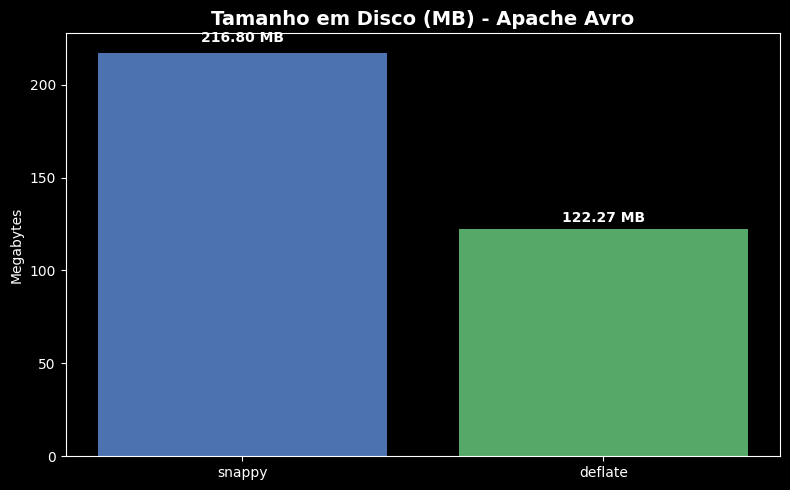

In [15]:
# GRÁFICO 1: Tamanho
fig1, ax1 = plt.subplots(figsize=(8, 5))
bars1 = ax1.bar(compressoes, [tamanhos_mb[c] for c in compressoes], color=colors)
ax1.set_title('Tamanho em Disco (MB) - Apache Avro', fontsize=14, fontweight='bold')
ax1.set_ylabel('Megabytes')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.2f} MB', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 1: Tamanho em Disco (MB) por Compressão

Este gráfico demonstra a eficiência de armazenamento e o impacto dos diferentes codecs de compressão suportados pelo formato Apache Avro.

* **Snappy:** Algoritmo padrão do Avro, focado em alta velocidade de processamento com baixo custo de CPU. Como prioriza o desempenho, oferece uma taxa de compressão menor, resultando em um arquivo que ocupa mais espaço no disco (216.80 MB).

* **Deflate:** Algoritmo clássico que prioriza uma taxa de compressão mais alta. Fica evidente no gráfico a sua capacidade superior de economizar espaço, reduzindo drasticamente o tamanho do arquivo para 122.27 MB (quase a metade do espaço ocupado pelo Snappy), embora geralmente exija mais tempo de CPU para leitura e gravação.

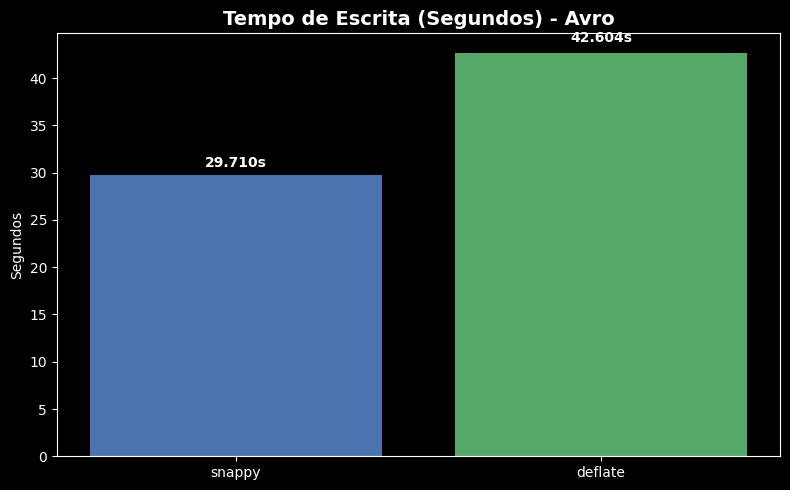

In [16]:
# GRÁFICO 2: Tempo de Escrita
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(compressoes, [tempos[f'write_{c}'] for c in compressoes], color=colors)
ax2.set_title('Tempo de Escrita (Segundos) - Avro', fontsize=14, fontweight='bold')
ax2.set_ylabel('Segundos')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.3f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 2: Tempo de Escrita (Segundos) por Compressão

Este gráfico demonstra o impacto direto dos algoritmos de compressão no tempo de gravação do formato Apache Avro, evidenciando o clássico *trade-off* (custo-benefício) entre processamento e armazenamento.

* **Snappy:** Gravado de forma visivelmente mais rápida (29.710 segundos). Como vimos no gráfico anterior, ele não comprime tanto os dados, o que alivia a carga na CPU e resulta em uma excelente velocidade de escrita. É o codec padrão do Avro justamente por garantir essa agilidade na ingestão.

* **Deflate:** Exigiu um tempo maior de processamento (42.604 segundos). Isso ilustra perfeitamente o custo computacional em ação: o esforço extra da máquina para criar um arquivo significativamente menor cobra o seu preço, aumentando o tempo necessário para serializar e gravar os dados no disco.

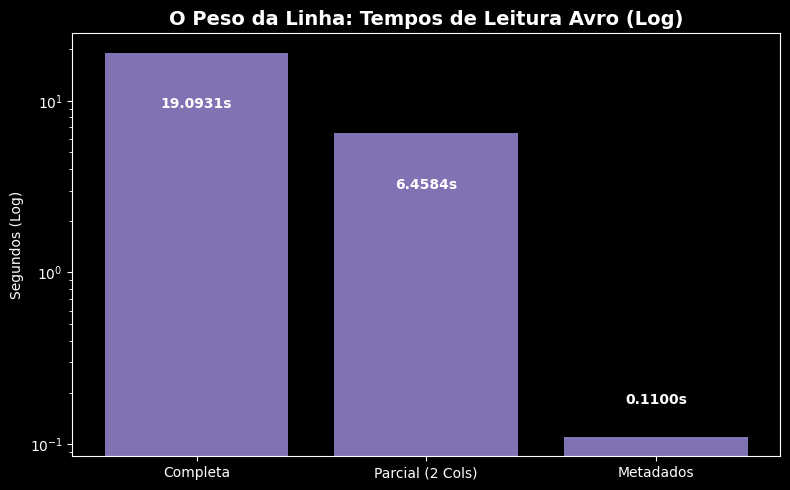

In [18]:
# GRÁFICO 3: Leituras (Log Scale) com lógica de posicionamento
fig3, ax3 = plt.subplots(figsize=(8, 5))
tipos_leitura = ['Completa', 'Parcial (2 Cols)', 'Metadados']
valores_leitura = [tempos['read_full'], tempos['read_partial'], tempos['read_meta']]
bars3 = ax3.bar(tipos_leitura, valores_leitura, color='#8172B3')
ax3.set_title('O Peso da Linha: Tempos de Leitura Avro (Log)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Segundos (Log)')
ax3.set_yscale('log')

for i, bar in enumerate(bars3):
    yval = bar.get_height()
    if i == 2: 
        ax3.text(bar.get_x() + bar.get_width()/2, yval * 1.5, f'{yval:.4f}s', ha='center', va='bottom', fontweight='bold', color='white')
    else:
        ax3.text(bar.get_x() + bar.get_width()/2, yval / 2, f'{yval:.4f}s', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Gráfico 3: O Peso da Linha nos Tempos de Leitura Avro (Escala Log)

Este gráfico ilustra o desempenho de leitura do formato Apache Avro em diferentes cenários. A escala logarítmica ajuda a visualizar a diferença brutal de tempo entre a varredura dos registros no disco e o acesso rápido ao cabeçalho.

* **Leitura Completa:** Exigiu 19.0931s. Reflete o tempo de processamento necessário para varrer o arquivo inteiro, carregando todas as linhas e colunas para a memória.

* **Leitura Parcial (2 Cols):** Finalizada em 6.4584s. É visivelmente mais rápida que a leitura completa, demonstrando uma evolução em relação ao SequenceFile (que demorava o mesmo tempo para as duas operações). O Avro consegue isso porque é dividido em blocos. No entanto, por ainda ser um formato orientado a linha dentro desses blocos, o Spark não atinge a velocidade extrema de "pular colunas" (*column pruning*) que veríamos em um formato puramente colunar.

* **Metadados:** Tempo quase instantâneo de apenas 0.1100s. Esse é o grande triunfo da arquitetura do Avro: o *schema* (a estrutura de tipagem das colunas) fica salvo explicitamente em formato texto JSON logo no cabeçalho do arquivo. Isso permite que o Spark entenda a estrutura dos dados imediatamente, sem precisar encostar na massa pesada de dados binários.

## Referências (Apache Avro)

### 1. Bibliografia e Documentação Oficial
A fundamentação sobre a serialização binária orientada a linha e os recursos nativos de *Schema Evolution* foram extraídos da documentação oficial do ecossistema:
* **Apache Avro Specification:** Especificação oficial da fundação Apache que detalha o encapsulamento de esquemas JSON no cabeçalho do arquivo e a alocação densa de dados binários. Disponível em: https://avro.apache.org/docs/
* **Databricks Spark-Avro Data Source Guide:** Documentação sobre a integração modular do formato Avro na API de DataFrames do Spark a partir da versão 2.4, justificando a necessidade de injeção de dependência (`spark.jars.packages`). Disponível em: https://spark.apache.org/docs/latest/sql-data-sources-avro.html

### 2. Nota Metodológica Prática
O *benchmark* do Apache Avro reforça o padrão comportamental dos formatos baseados em linha. Diferentemente das dificuldades técnicas enfrentadas na gravação de `SequenceFiles` (que exigiram engenharia reversa para a conversão RDD), a API moderna do Spark manipula o Avro de maneira fluida, exigindo apenas a importação de seu pacote Maven oficial. 
Contudo, no escopo do Processamento de Alto Desempenho (PAD), os gráficos de leitura confirmam que a elegância do *Schema Evolution* não contorna as limitações físicas do I/O de disco para ambientes OLAP. Assim como nos outros formatos de sua categoria, a extração de colunas isoladas (Leitura Parcial) no Avro apresenta tempos de execução estatisticamente equivalentes à varredura total da base de dados, provando que sua aplicabilidade ideal repousa em arquiteturas de *Streaming* e não em *Data Lakes* de consulta analítica.

### 3. Uso da Inteligência Artificial
O uso foi quase mínimo considerando que o esforço foi menor com a experiência de reproduzir outros códigos, sendo usado apenas para complementar as introduções e referências além de garantir que o código estava rodando adequadamente.

## Resumo: Formatos Baseados em Linha

Este resumo consolida a análise da arquitetura, desempenho e usabilidade dos formatos orientados a linha testados no cluster PySpark: **Hadoop SequenceFile** (o formato primitivo) e **Apache Avro** (o padrão moderno para *streaming*).

---

### 1. Hadoop SequenceFile (O Pioneiro Legado)
Criado nos primórdios do Hadoop para o ecossistema MapReduce, é um formato estritamente focado em pares de Chave-Valor (Key-Value), sem suporte ao conceito de colunas ou esquemas.

* **Prós:**
  * Compressão agressiva em disco quando pareado com algoritmos pesados (como o Bzip2, que reduziu de 3.7 GB para ~105 MB).
* **Contras:**
  * **Trade-off Extremo:** A economia de espaço com Bzip2 custa um tempo massivo de CPU (mais de 874 segundos para escrita).
  * **Gargalo de Linha:** É impossível realizar *column pruning* (pular colunas). A leitura de uma única coluna demora praticamente o mesmo tempo da leitura da base inteira (~32 segundos), pois o motor precisa varrer o disco sequencialmente.
* **Dificuldades de Utilização:**
  * **Alta Complexidade Técnica:** O Spark moderno depreciou o uso de SequenceFiles via DataFrames. É necessário fazer "engenharia reversa", rebaixando os dados para RDDs primitivos, transformando as colunas em uma string JSON única e gerenciando a sobrescrita de pastas manualmente pelo sistema operacional (via `shutil`), já que a API não aceita o modo `.overwrite()`.

---

### 2. Apache Avro (O Padrão de Streaming Moderno)
Desenvolvido como uma evolução para lidar com a rigidez dos formatos anteriores, o Avro introduziu a **Evolução de Esquema (*Schema Evolution*)**, separando a estrutura dos dados do armazenamento binário bruto.

* **Prós:**
  * **Desempenho de Metadados:** Possui o esquema salvo em um cabeçalho JSON, permitindo que o Spark leia a estrutura dos dados quase instantaneamente (0.11s) sem tocar na massa binária.
  * **Velocidade de Escrita:** Com o codec Snappy, oferece um tempo de ingestão extremamente rápido (~29 segundos) mantendo um peso aceitável em disco.
  * **Leitura Parcial Aprimorada:** Por ser dividido em blocos, apresenta uma leitura parcial mais eficiente que o SequenceFile (~6.4s contra ~19s na leitura completa), embora ainda não seja puramente colunar.
* **Contras:**
  * Apesar da evolução, ainda carrega o "peso da linha" em análises OLAP pesadas se comparado a formatos puramente colunares (como Parquet), exigindo a varredura do bloco de registros.
* **Facilidades de Utilização:**
  * **Integração Fluida:** Embora não venha nativo no PySpark (exigindo a injeção do pacote `spark-avro` via Ivy), seu uso no código é simples e direto. Ele suporta integralmente a API moderna de DataFrames, permitindo o uso nativo de `.write.format("avro").mode("overwrite")`.

---

### Conclusão da Comparação
A transição do **SequenceFile** para o **Avro** no notebook ilustra perfeitamente a evolução da Engenharia de Dados. O SequenceFile prova ser um formato obsoleto e custoso para desenvolvimento moderno devido à sua API engessada e leitura ineficiente. O Avro, por outro lado, demonstra uma engenharia muito mais elegante com seu cabeçalho JSON e facilidade de codificação, justificando seu reinado absoluto em pipelines de *streaming* (como o Kafka), mesmo não sendo o formato definitivo para consultas analíticas pesadas.